In [2]:
import tensorflow as tf

tf.keras.backend.clear_session() 
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True) 
    # Check GPU availability
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Limit GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True) # for accurate timing later

import numpy as np
import matplotlib.pyplot as plt

DTYPE = "float32"
tf.keras.backend.set_floatx(DTYPE)
pi = tf.constant(np.pi, dtype=DTYPE)
viscosity = 0.01 / pi

In [2]:
# initial condition
def fun_u_0(x):
    return -tf.sin(pi * x)

# boundary condition
def fun_u_b(t, x):
    n = x.shape[0]
    return tf.zeros(
        (n, 1), dtype=DTYPE
    )  # n (as many as x) rows and 1 column of zeros because u(t, +-1) = 0

# residual of PDE
def fun_r(t, x, u, u_t, u_x, u_xx):
    return u_t + u * u_x - viscosity * u_xx

In [3]:
# number of data points
N_0 = 5000
N_b = 50
N_r = 10000

tmin = 0.0
tmax = 1.0
xmin = -1.0
xmax = 1.0

# lower and upper bounds
lb = tf.constant(
    [tmin, xmin], dtype=DTYPE
)  # creates constant tensor, here from python list
ub = tf.constant([tmax, xmax], dtype=DTYPE)

tf.random.set_seed(0)

# boundary, ie u(0, x) = -sin(pi*x) for random x's
t_0 = tf.ones((N_0, 1), dtype=DTYPE) * lb[0]
x_0 = tf.random.uniform((N_0, 1), lb[1], ub[1], dtype=DTYPE)
X_0 = tf.concat([t_0, x_0], axis=1)  # concatenate in a N_0 x 2 matrix

u_0 = fun_u_0(x_0)

# boundary, ie u(t, +-1) = 0 for random t's
t_b = tf.random.uniform((N_b, 1), lb[0], ub[0], dtype=DTYPE)
bernoulli_tensor = tf.cast(
    tf.less(tf.random.uniform([N_b, 1]), 0.5), dtype=DTYPE
)  # picks x = -1 or x = 1 with equal probabilty
x_b = lb[1] + (ub[1] - lb[1]) * bernoulli_tensor
X_b = tf.concat([t_b, x_b], axis=1)

u_b = fun_u_b(t_b, x_b)

# collocation points, ie u(t,x) for random t's and x's
t_r = tf.random.uniform((N_r, 1), lb[0], ub[0], dtype=DTYPE)
x_r = tf.random.uniform((N_r, 1), lb[1], ub[1], dtype=DTYPE)
X_r = tf.concat([t_r, x_r], axis=1)

X_data = [X_0, X_b]
u_data = [u_0, u_b]

Text(0.5, 1.0, 'Positions of collocation points and boundary data')

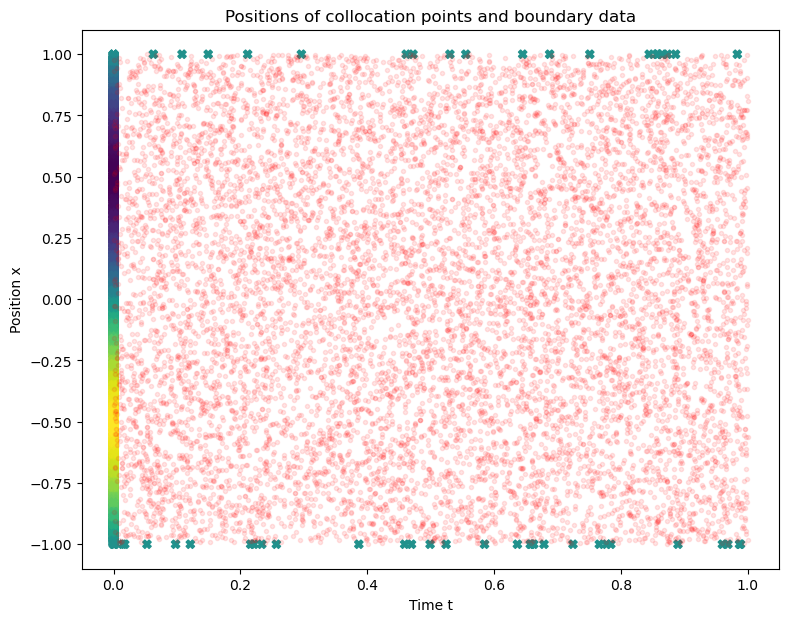

In [4]:
fig = plt.figure(figsize=(9, 7))
plt.scatter(
    t_0, x_0, c=u_0, marker="X", vmin=-1, vmax=1
)  # color is a representation of values of the almost continuous
   # (1000s of data points) function u = -sin(pi*x) for t=0
plt.scatter(
    t_b, x_b, c=u_b, marker="X", vmin=-1, vmax=1
)  # color is uniform because u = 0 for x=+-1
plt.scatter(t_r, x_r, c="r", marker=".", alpha=0.1)
plt.xlabel("Time t")
plt.ylabel("Position x")
plt.title("Positions of collocation points and boundary data")

plt.savefig('Xdata_burgers.pdf', bbox_inches='tight', dpi = 300)

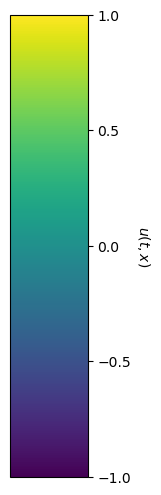

In [1]:
# Create a standalone colorbar matching your plot's colormap and range
fig, ax = plt.subplots(figsize=(1, 6))
# Create a scalar mappable with the same range as your scatter plot
norm = plt.Normalize(vmin=-1, vmax=1)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
# Add colorbar
cbar = plt.colorbar(sm, cax=ax)
cbar.set_label('$u(t,x)$', rotation=270, labelpad=15)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
# Save with same DPI and style
plt.savefig('colorbar_burgers.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [5]:
def init_model(num_hidden_layers=8, num_neurons_per_layer=20):
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(2,)))  # each input is of kind (t,x)
    scaling_layer = tf.keras.layers.Lambda(
        lambda x: 2.0 * (x - lb) / (ub - lb) - 1.0
    )  # maps t and x linearly, from [0,1] and [-1,1], to [-1,1]
    model.add(scaling_layer)

    for i in range(num_hidden_layers):
        model.add(
            tf.keras.layers.Dense(
                num_neurons_per_layer,
                activation=tf.keras.activations.get("tanh"),
                kernel_initializer="glorot_normal",
            )
        )  # determines how weights are initialized (once) at the beginning of training.
    # This one draws samples from a truncated normal distribution centered on 0 with stddev = sqrt(2 / (fan_in + fan_out))
    # where fan_in is the number of input units in the weight tensor and fan_out is the number of output units in the weight tensor:
    # few weights -> large variance is sensible.
    model.add(tf.keras.layers.Dense(1))  # output layer

    return model

In [7]:
def get_r(model, X_r):
    with tf.GradientTape(
        persistent=True
    ) as tape:  # "persistent" is a boolean simply to check if the gradient has been created.
        # same as:
        # tape = tf.GradientTape(persistent=True)
        # for i in tape:
        # ...
        t, x = X_r[:, 0:1], X_r[:, 1:2]  # not just 0 and 1 in order to keep dimension
        tape.watch(t)  # gradient computed in t
        tape.watch(x)
        u = model(tf.stack([t[:, 0], x[:, 0]], axis=1))  # WHY NOT model(X_r)) ?
        u_x = tape.gradient(
            u, x
        )  # gradient of u with respect to x. In the with-as block because needed for second derivative because all gradient computations must happen inside
    u_t = tape.gradient(u, t)
    u_xx = tape.gradient(u_x, x)
    del tape
    return fun_r(
        t, x, u, u_t, u_x, u_xx
    )  # residual of parametrized u, in sampled points

In [8]:
def compute_loss(model, X_r, X_data, u_data):
    r = get_r(model, X_r)
    phi_r = tf.reduce_mean(tf.square(r))  # technically tf.square(r-tf.zeros(...))
    loss = phi_r  # phi_r
    for i in range(len(X_data)):  # adds phi_b and phi_0, because X_data = [X_0, X_b]
        u_pred = model(X_data[i])
        loss += tf.reduce_mean(tf.square(u_data[i] - u_pred))
    return loss

In [9]:
def get_grad(
    model, X_r, X_data, u_data
):  # "usual" gradient with respect to trainable parameters
    with tf.GradientTape(persistent=True) as tape:
        # tape.watch(model.trainable_variables) # to access trainable parameters - WOULD FAIL IF UNCOMMENTED!
        loss = compute_loss(model, X_r, X_data, u_data)
    g = tape.gradient(loss, model.trainable_variables)
    del tape
    return loss, g

In [10]:
model = init_model()
lr = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    [1000, 3000], [1e-2, 1e-3, 5e-4]
)
optim = tf.keras.optimizers.Adam(learning_rate=lr)
# tf.executing_eagerly()

In [11]:
#TESTING BEGINS HERE

# number of data points
N_0_t = 1000
N_b_t = 10
N_r_t = 2000

# boundary, ie u(0, x) = -sin(pi*x) for random x's
t_0_t = tf.ones((N_0_t, 1), dtype=DTYPE) * lb[0]
x_0_t = tf.random.uniform((N_0_t, 1), lb[1], ub[1], dtype=DTYPE)
X_0_t = tf.concat([t_0_t, x_0_t], axis=1)  # concatenate in a N_0 x 2 matrix

u_0_t = fun_u_0(x_0_t)

# boundary, ie u(t, +-1) = 0 for random t's
t_b_t = tf.random.uniform((N_b_t, 1), lb[0], ub[0], dtype=DTYPE)
bernoulli_tensor_t = tf.cast(
    tf.less(tf.random.uniform([N_b_t, 1]), 0.5), dtype=DTYPE
)  # picks x = -1 or x = 1 with equal probabilty

x_b_t = lb[1] + (ub[1] - lb[1]) * bernoulli_tensor_t
X_b_t = tf.concat([t_b_t, x_b_t], axis=1)

u_b_t = fun_u_b(t_b_t, x_b_t)

# collocation points, ie u(t,x) for random t's and x's
t_r_t = tf.random.uniform((N_r_t, 1), lb[0], ub[0], dtype=DTYPE)
x_r_t = tf.random.uniform((N_r_t, 1), lb[1], ub[1], dtype=DTYPE)
X_r_t = tf.concat([t_r_t, x_r_t], axis=1)

X_data_t = [X_0_t, X_b_t]
u_data_t = [u_0_t, u_b_t]

Text(0.5, 1.0, 'TESTING - Positions of collocation points and boundary data')

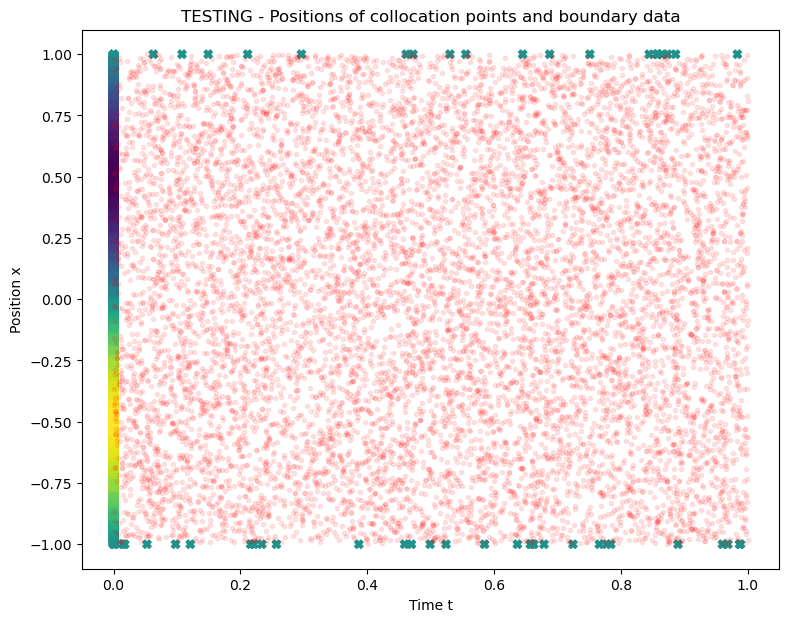

In [12]:
fig = plt.figure(figsize=(9, 7))
plt.scatter(
    t_0, x_0, c=u_0, marker="X", vmin=-1, vmax=1
)  # color is a representation of values of the almost continuous
#  (1000s of data points) function u = -sin(pi*x) for t=0
plt.scatter(
    t_b, x_b, c=u_b, marker="X", vmin=-1, vmax=1
)  # color is uniform because u = 0 for x=+-1
plt.scatter(t_r, x_r, c="r", marker=".", alpha=0.1)
plt.xlabel("Time t")
plt.ylabel("Position x")
plt.title("TESTING - Positions of collocation points and boundary data")
plt.savefig('Xdata_burgers_t.pdf', bbox_inches='tight', dpi = 300)

In [13]:
def compute_loss_t(model, X_r_t, X_data_t, u_data_t): # same but for testingb
    r_t = get_r(model, X_r_t)
    phi_r_t = tf.reduce_mean(tf.square(r_t))  # technically tf.square(r-tf.zeros(...))
    loss_t = phi_r_t  # phi_r
    for i in range(len(X_data_t)):  # adds phi_b and phi_0, because X_data = [X_0, X_b]
        u_pred_t = model(X_data_t[i])
        loss_t += tf.reduce_mean(tf.square(u_data_t[i] - u_pred_t))
    return loss_t

In [16]:
if __name__ == "__main__":
    from time import time

    @tf.function  # python decorator: converts following function to tensorflow function for efficiency
    def train_step():
        loss, grad_theta = get_grad(model, X_r, X_data, u_data)
        optim.apply_gradients(
            grads_and_vars=zip(grad_theta, model.trainable_variables)
        )  # takes a list of gradients and trainable variables and returns a tf.Variable, representing the current iteration.
        return loss
    
    N = 5000
    hist = []
    hist_t = []
    t0 = time()
    for i in range(N + 1):
        loss = train_step()
        loss_t = compute_loss_t(model, X_r_t, X_data_t, u_data_t)
        hist.append(loss.numpy())
        hist_t.append(loss_t.numpy())
        
        if i % 50 == 0:
            print(
                f"Iteration {i}: training loss = {loss}"
            )  # prints loss function value every 50 iterations
    
        if i % 500 == 0:
            print(
                f"Iteration {i}: validation error = {loss_t}"
            ) 
    
    print(f"Computation time: {time()-t0} s")

Iteration 0: training loss = 0.11867434531450272
Iteration 0: validation error = 0.10121316462755203
Iteration 50: training loss = 0.08805697411298752
Iteration 100: training loss = 0.08067278563976288
Iteration 150: training loss = 0.0975927785038948
Iteration 200: training loss = 0.05743260681629181
Iteration 250: training loss = 0.07514573633670807
Iteration 300: training loss = 0.042958639562129974
Iteration 350: training loss = 0.03362796828150749
Iteration 400: training loss = 0.029005620628595352
Iteration 450: training loss = 0.09692919999361038
Iteration 500: training loss = 0.049642037600278854
Iteration 500: validation error = 0.05154344066977501
Iteration 550: training loss = 0.03510325774550438
Iteration 600: training loss = 0.04829970374703407
Iteration 650: training loss = 0.13003559410572052
Iteration 700: training loss = 0.015921667218208313
Iteration 750: training loss = 0.039198361337184906
Iteration 800: training loss = 0.015577255748212337
Iteration 850: training l

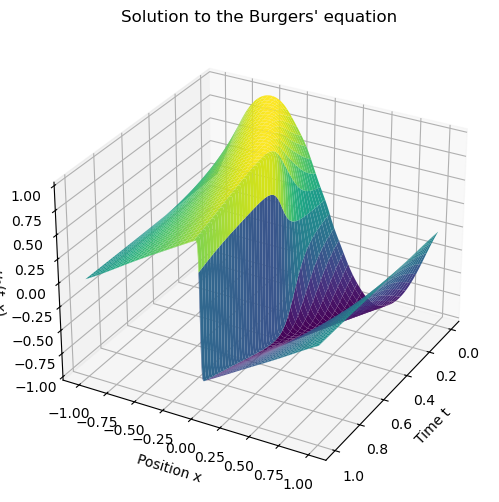

In [17]:
from mpl_toolkits.mplot3d import Axes3D

N = 600  # number of grid marks
tspace = np.linspace(lb[0], ub[0], N + 1)
xspace = np.linspace(lb[1], ub[1], N + 1)
T, X = np.meshgrid(tspace, xspace)
# note: flattened X has 600 elements = -1, then 600 elements = -0.99666...,
# while T goes from 0 to 1 for 600 times; opposite behavior if indexing='ij'.
stack = np.vstack([T.flatten(), X.flatten()])  # first row is T, second is X
Xgrid = stack.T  # transposes stack
upred = model(tf.cast(Xgrid, DTYPE))  # float type conversion

U = upred.numpy().reshape(N + 1, N + 1)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(
    111, projection="3d"
)  # place subplot in position 1-1-1; with custom projection '3d'
ax.plot_surface(T, X, U, cmap="viridis")
# type of color map (default is in one tone)
ax.view_init(29, 29)  # pov, in degress up and to the side (rotated clockwise)
ax.set_xlabel("Time t")
ax.set_ylabel("Position x")
ax.set_zlabel("$u_\\theta(t,x)$")
ax.set_title("Solution to the Burgers' equation");
plt.savefig('Burgers_Solution.pdf', bbox_inches = 'tight', dpi = 300);

Text(0, 0.5, '$L_{testing} (n_{epoch})$')

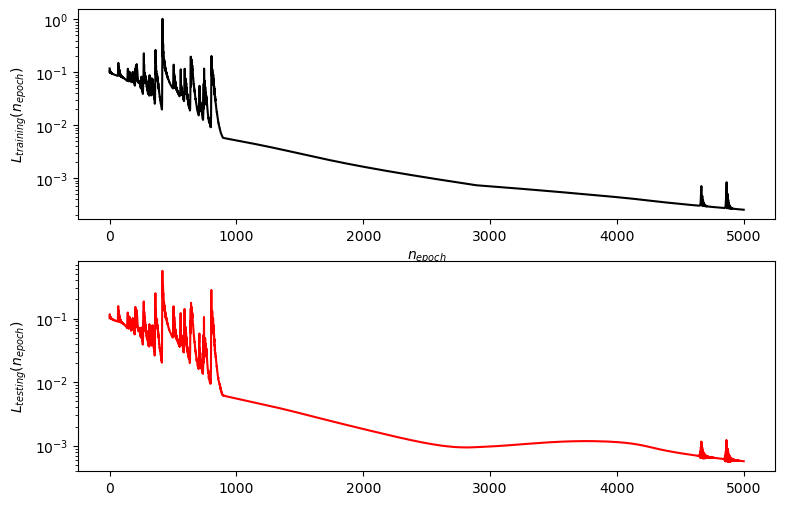

In [18]:
fig = plt.figure(figsize=(9, 6))
ax1 = fig.add_subplot(211)
ax1.semilogy(
    range(len(hist)), hist, "k-"
)  # k is for black marker, semilogy is analog of plot
ax2 = fig.add_subplot(212, sharex=ax1)  
ax2.semilogy(range(len(hist_t)), hist_t, 'r-') 

ax1.set_xlabel("$n_{epoch}$")
ax1.set_ylabel("$L_{training} (n_{epoch})$")
ax2.set_ylabel("$L_{testing} (n_{epoch})$")

In [ ]:
N_test = 50000
X_test_dense = tf.random.uniform((N_test, 2), lb, ub, dtype=DTYPE)
final_residual = get_r(model, X_test_dense)
mean_residual = tf.reduce_mean(tf.abs(final_residual))
print(f"Mean absolute residual: {mean_residual.numpy()}")